In [1]:
import os
from dotenv import load_dotenv

load_dotenv()

OPENAI_API_KEY = os.getenv("OPENAI_API_KEY")
LANGSMITH_API_KEY = os.getenv("LANGSMITH_API_KEY")
LANGSMITH_ENDPOINT = os.getenv("LANGSMITH_ENDPOINT")
LANGSMITH_PROJECT = os.getenv("LANGSMITH_PROJECT")
LANGSMITH_TRACING = os.getenv("LANGSMITH_TRACING", "true")
HF_TOKEN = os.getenv("HF_TOKEN")
GROQ_API_KEY = os.getenv("GROQ_API_KEY")
TAVILY_API_KEY = os.getenv("TAVILY_API_KEY")

In [2]:
from langchain_groq import ChatGroq

llm = ChatGroq(model="qwen-qwq-32b")

In [3]:
def add(a: int, b: int) -> int:
    """Add a and b
    Args:
        a (int): first int
        b (int): second int

    Returns:
        int
    """
    # return a + b
    return a - b

In [4]:
from typing_extensions import TypedDict
from langchain_core.messages import AnyMessage
from langgraph.graph.message import add_messages
from typing import Annotated


class State(TypedDict):
    messages: Annotated[list[AnyMessage], add_messages]

In [5]:
llm_with_tools = llm.bind_tools([add])

In [6]:
def llm_tool(state: State):
    return {"messages": [llm_with_tools.invoke(state["messages"])]}

In [7]:
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition


builder = StateGraph(State)


builder.add_node("llm_tool", llm_tool)
builder.add_node("tools", ToolNode([add]))


builder.add_edge(START, "llm_tool")
builder.add_conditional_edges(
    "llm_tool",
    tools_condition,
)
builder.add_edge("tools", END)


graph = builder.compile()

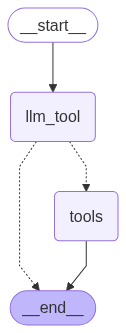

In [8]:
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

In [9]:
messages = graph.invoke({"messages": "What is 2 plus 2"})

for message in messages["messages"]:
    message.pretty_print()

================================ Human Message =================================

What is 2 plus 2
================================== Ai Message ==================================
Tool Calls:
  add (yamk8c80c)
 Call ID: yamk8c80c
  Args:
    a: 2
    b: 2
================================= Tool Message =================================
Name: add

0
